   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

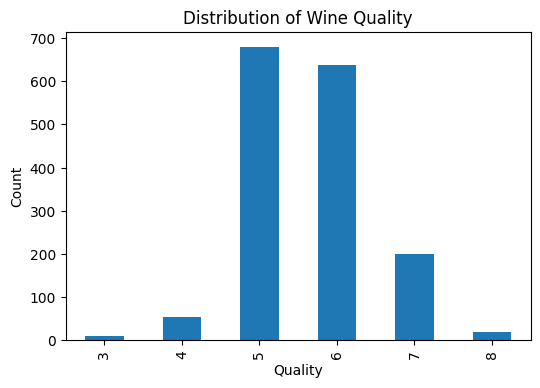

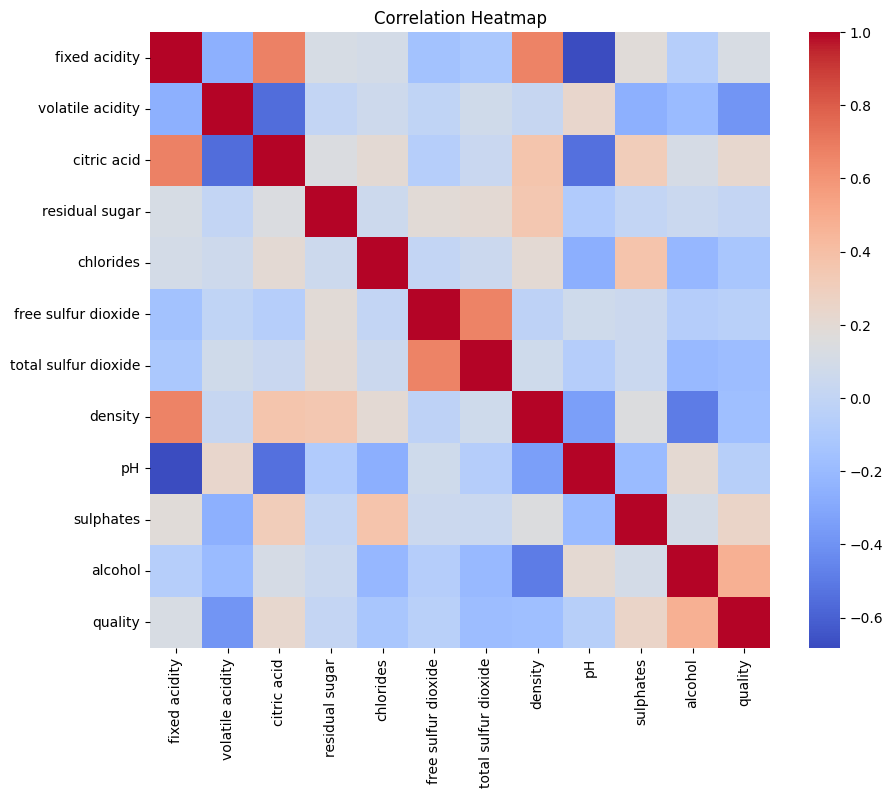


Correlation with Quality:

quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64

Average residual sugar (best quality): 2.5777777777777775
Average residual sugar (worst quality): 2.6350000000000002


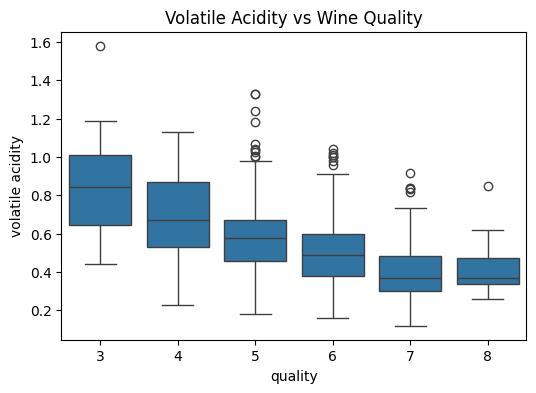


Decision Tree Accuracy: 0.559375
Random Forest Accuracy: 0.659375


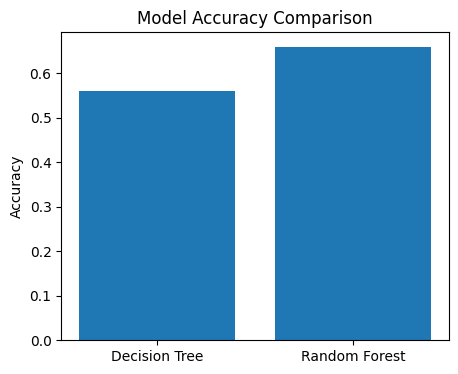

In [7]:
# ================================
# Wine Quality Prediction
# Decision Tree & Random Forest
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# ----------------
# Load Dataset
# ----------------
df = pd.read_csv('/content/drive/MyDrive/ML_Project/wine_data.csv')


print(df.head())
print("\nDataset shape:", df.shape)

# ----------------
# Q1: Most frequent, highest & lowest wine quality
# ----------------
quality_counts = df['quality'].value_counts().sort_index()
print("\nQuality distribution:\n", quality_counts)

most_frequent_quality = quality_counts.idxmax()
print("\nMost frequent wine quality:", most_frequent_quality)
print("Lowest quality:", df['quality'].min())
print("Highest quality:", df['quality'].max())

# Bar plot for quality distribution
plt.figure(figsize=(6,4))
quality_counts.plot(kind='bar')
plt.title('Distribution of Wine Quality')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.show()

# ----------------
# Q2: Correlation analysis
# ----------------
corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

print("\nCorrelation with Quality:\n")
print(corr['quality'].sort_values(ascending=False))

# ----------------
# Q3: Average residual sugar for best & worst quality
# ----------------
best_quality = df['quality'].max()
worst_quality = df['quality'].min()

avg_residual_best = df[df['quality'] == best_quality]['residual sugar'].mean()
avg_residual_worst = df[df['quality'] == worst_quality]['residual sugar'].mean()

print("\nAverage residual sugar (best quality):", avg_residual_best)
print("Average residual sugar (worst quality):", avg_residual_worst)

# ----------------
# Q4: Volatile acidity vs quality
# ----------------
plt.figure(figsize=(6,4))
sns.boxplot(x='quality', y='volatile acidity', data=df)
plt.title('Volatile Acidity vs Wine Quality')
plt.show()

# ----------------
# Feature & Target Split
# ----------------
X = df.drop('quality', axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------
# Q5: Decision Tree Model
# ----------------
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("\nDecision Tree Accuracy:", dt_accuracy)

# ----------------
# Random Forest Model
# ----------------
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

# ----------------
# Accuracy Comparison
# ----------------
models = ['Decision Tree', 'Random Forest']
accuracies = [dt_accuracy, rf_accuracy]

plt.figure(figsize=(5,4))
plt.bar(models, accuracies)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()


In [6]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive
